# Spam Project

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data=pd.read_csv('/content/drive/MyDrive/Spam Classifier/SpamTest.csv')

In [ ]:
data.head()

,sms_type,description
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
data.shape

(5572, 2)

In [ ]:
data.value_counts(['sms_type'])

,count
sms_type,
ham,4825
spam,747


In [ ]:
data.isnull().sum()

,0
sms_type,0
description,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sms_type     5572 non-null   object
 1   description  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
# renaming the columns
data.columns=['sms_type','sms_text']

In [ ]:
data.head()

,sms_type,sms_text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#c Checking the dulicated values
data.duplicated().sum()

np.int64(414)

In [ ]:
# deleting the duplicate values
data=data.drop_duplicates(keep='first')

In [ ]:
data.shape

(5158, 2)

In [ ]:
# encoding the sms_type using sklearn
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
data['sms_type']=encoder.fit_transform(data['sms_type'])

In [ ]:
data.head()

,sms_type,sms_text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


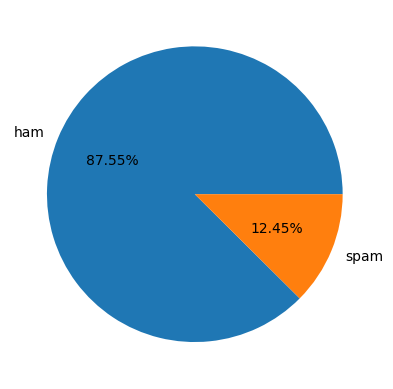

In [ ]:
# plotting the pie chart for the given data
import matplotlib.pyplot as plt
plt.pie(data['sms_type'].value_counts(),labels=['ham','spam'],autopct='%1.2f%%')
plt.show()

In [ ]:
import nltk

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
data['num_of_char']=data['sms_text'].apply(len)

In [ ]:
data.head()

,sms_type,sms_text,num_of_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
# counting the number of words
data['num_of_words']=data['sms_text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [ ]:
data.head()

,sms_type,sms_text,num_of_char,num_of_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [ ]:
data['num_of_sent']=data['sms_text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [ ]:
# describing the columns of the data
data[['num_of_char','num_of_words','num_of_sent']].describe()

,num_of_char,num_of_words,num_of_sent
count,5158.000000,5158.000000,5158.000000
mean,79.155874,18.568437,1.970725
std,58.395266,13.405342,1.456005
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
# checking for ham
data[data['sms_type']==0][['num_of_char','num_of_words','num_of_sent']].describe()

,num_of_char,num_of_words,num_of_sent
count,4516.000000,4516.000000,4516.000000
mean,70.874668,17.267715,1.827724
std,56.711547,13.588065,1.394338
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
data[data['sms_type']==1][['num_of_char','num_of_words','num_of_sent']].describe()

,num_of_char,num_of_words,num_of_sent
count,642.000000,642.000000,642.000000
mean,137.408100,27.718069,2.976636
std,29.977971,7.033902,1.484527
min,13.000000,2.000000,1.000000
25%,131.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


In [ ]:
import seaborn as sns

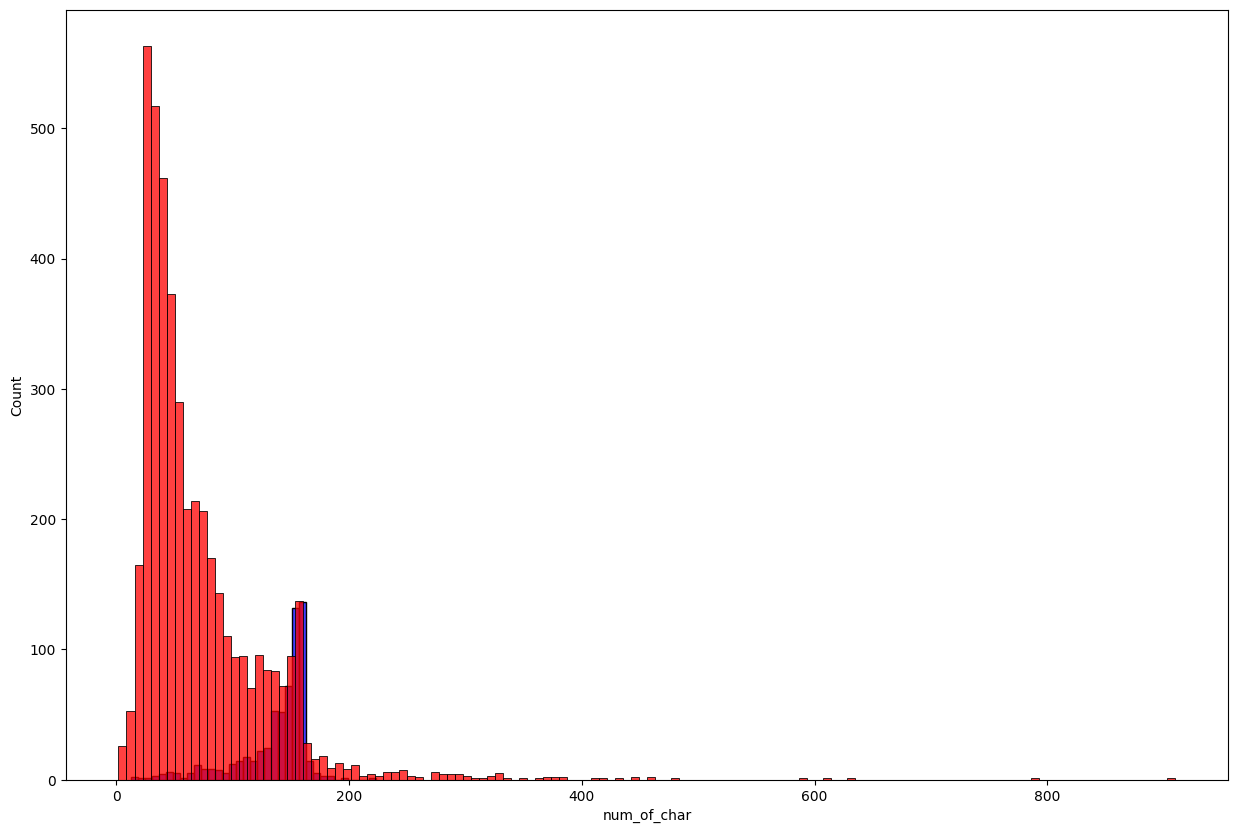

In [ ]:
plt.figure(figsize=(15,10))
sns.histplot(data[data['sms_type']==1]['num_of_char'],color='blue');
sns.histplot(data[data['sms_type']==0]['num_of_char'],color='red');
plt.show()

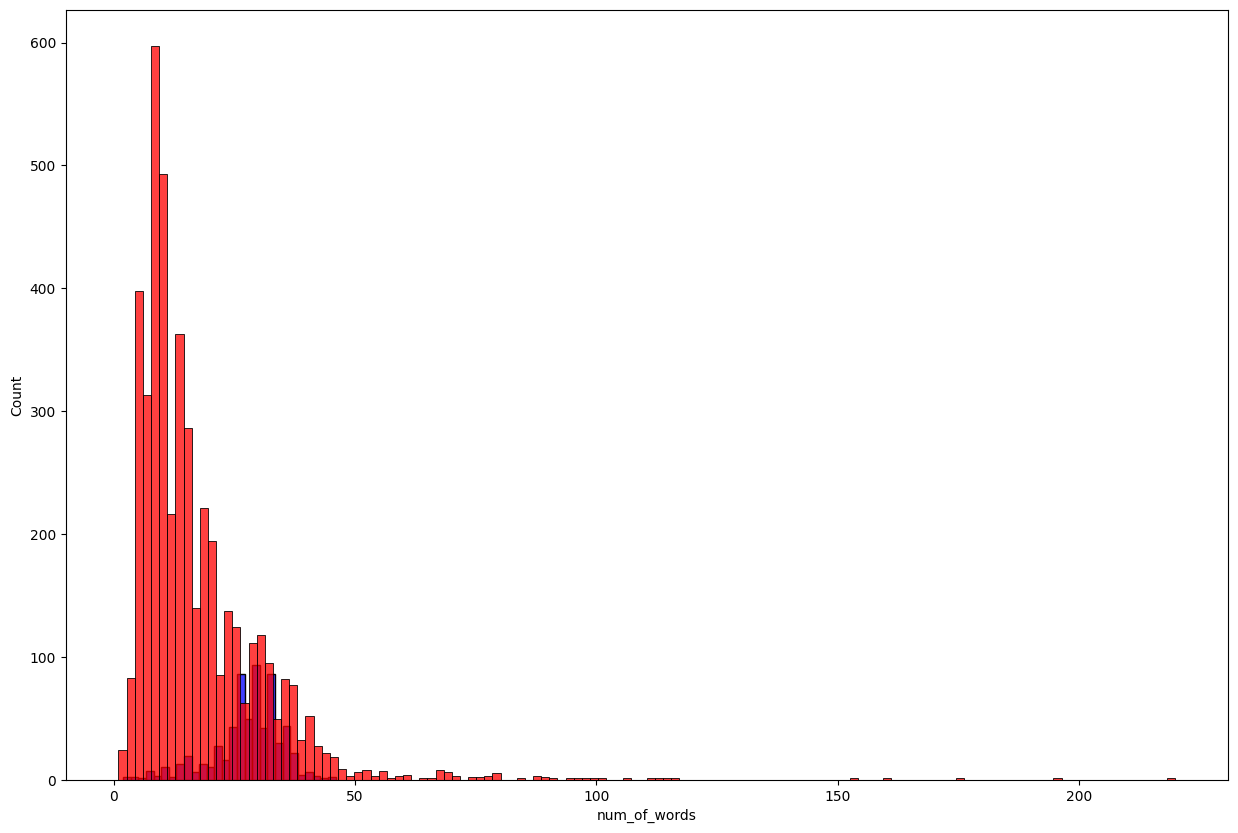

In [ ]:
plt.figure(figsize=(15,10))
sns.histplot(data[data['sms_type']==1]['num_of_words'],color='blue');
sns.histplot(data[data['sms_type']==0]['num_of_words'],color='red');
plt.show()

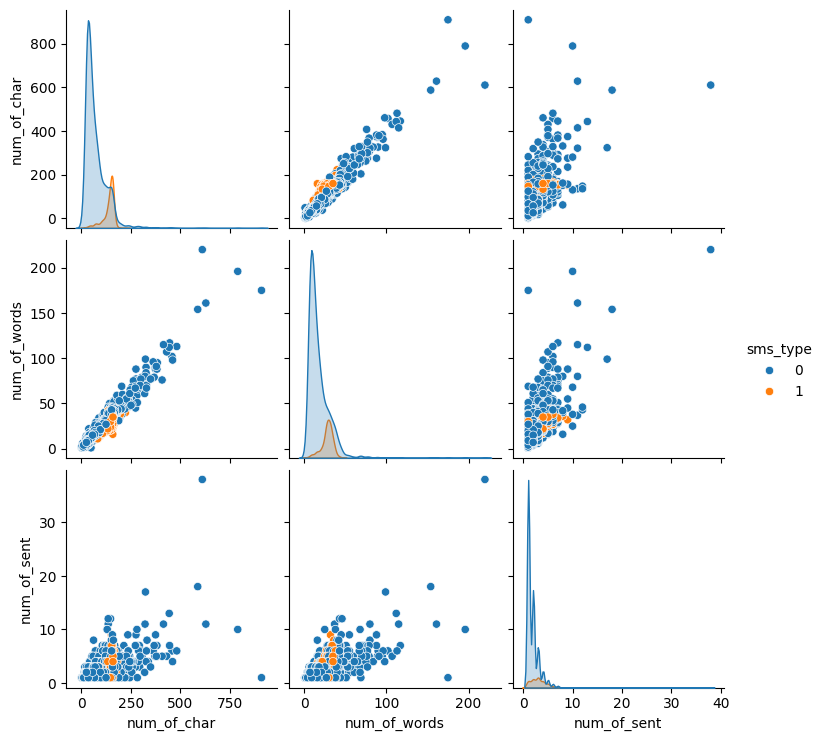

In [ ]:
sns.pairplot(data,hue='sms_type');

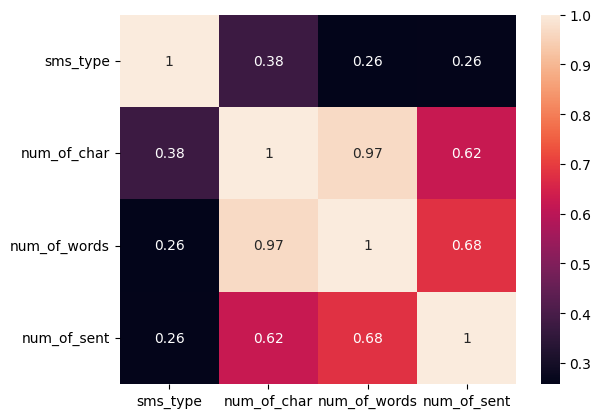

In [ ]:
sns.heatmap(data[['sms_type','num_of_char','num_of_words','num_of_sent']].corr(),annot=True);

# Data Processing

In [ ]:
import string

In [ ]:
def transform_text(text):
  text=text.lower()
  text=nltk.word_tokenize(text)
  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)
  text=y[:]
  y.clear()
  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)
  text=y[:]

  y.clear()
  for i in text:
    y.append(ps.stem(i))
  return ' '.join(y)

In [ ]:
from nltk.corpus import stopwords

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [ ]:
print(transform_text('HelLo $$ This IS Vikas RAI'))

hello vika rai


In [ ]:
ps.stem('raining')

'rain'

In [ ]:
data['tranformed_text']=data['sms_text'].apply(transform_text)

In [ ]:
data.head()

,sms_type,sms_text,num_of_char,num_of_words,num_of_sent,tranformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
from wordcloud import WordCloud

In [ ]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [ ]:
spam_wc=wc.generate(data[data['sms_type']==1]['tranformed_text'].str.cat(sep=' '))

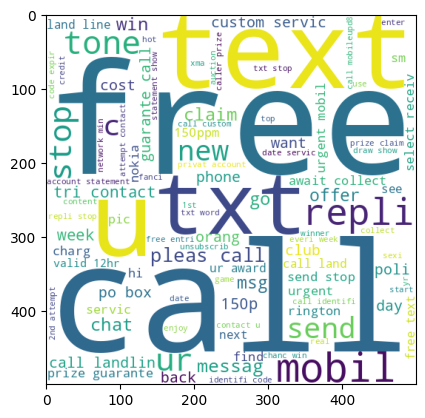

In [ ]:
plt.imshow(spam_wc);

In [ ]:
ham_wc=wc.generate(data[data['sms_type']==0]['tranformed_text'].str.cat(sep=' '))

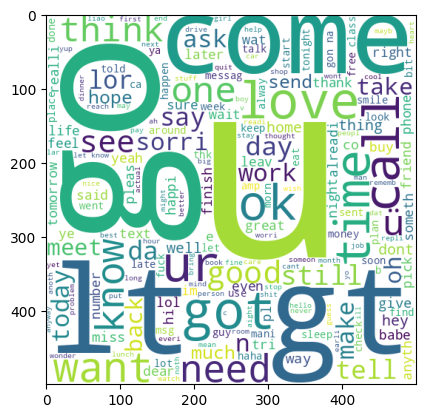

In [ ]:
plt.imshow(ham_wc);

In [ ]:
data.head()

,sms_type,sms_text,num_of_char,num_of_words,num_of_sent,tranformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
spam_corpus=[]
for msg in data[data['sms_type']==1]['tranformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [ ]:
len(spam_corpus)

9808

In [ ]:
from collections import Counter

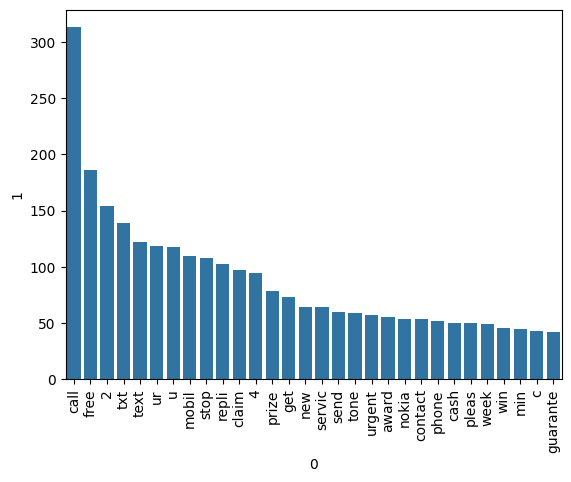

In [ ]:
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1]);
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
ham_corpus=[]
for msg in data[data['sms_type']==0]['tranformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [ ]:
len(ham_corpus)

35940

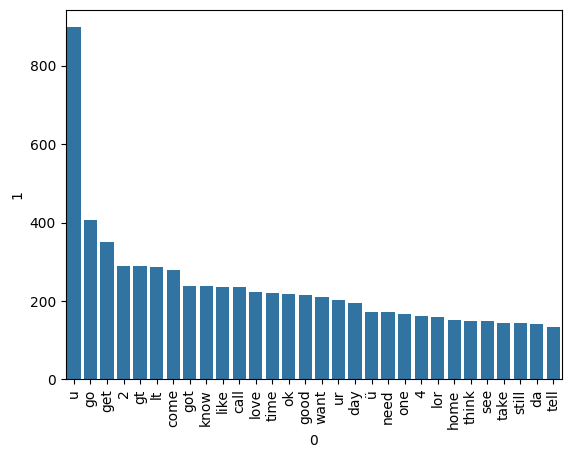

In [ ]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1]);
plt.xticks(rotation='vertical')
plt.show()

# Model Bulding

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [ ]:
cv=CountVectorizer()
tfidf=TfidfVectorizer()

In [ ]:
X=cv.fit_transform(data['tranformed_text']).toarray()

In [ ]:
X.shape

(5158, 6783)

In [ ]:
y=data['sms_type'].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix, precision_score

In [ ]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [ ]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.874031007751938
[[783 116]
 [ 14 119]]
0.5063829787234042


In [ ]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9757751937984496
[[884  15]
 [ 10 123]]
0.8913043478260869


In [ ]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9738372093023255
[[897   2]
 [ 25 108]]
0.9818181818181818


In [ ]:
X_1=tfidf.fit_transform(data['tranformed_text']).toarray()

In [ ]:
y_1=data['sms_type'].values

In [ ]:
X_1train, X_1test, y_1train, y_1test=train_test_split(X_1,y_1,test_size=0.2,random_state=2)

In [ ]:
gnb.fit(X_1train,y_1train)
y_pred4=gnb.predict(X_1test)
print(accuracy_score(y_1test,y_pred4))
print(confusion_matrix(y_1test,y_pred4))
print(precision_score(y_1test,y_pred4))

0.874031007751938
[[783 116]
 [ 14 119]]
0.5063829787234042


In [ ]:
mnb.fit(X_1train,y_1train)
y_pred5=mnb.predict(X_1test)
print(accuracy_score(y_1test,y_pred5))
print(confusion_matrix(y_1test,y_pred5))
print(precision_score(y_1test,y_pred5))

0.9593023255813954
[[899   0]
 [ 42  91]]
1.0


In [ ]:
bnb.fit(X_1train,y_1train)
y_pred6=bnb.predict(X_1test)
print(accuracy_score(y_1test,y_pred6))
print(confusion_matrix(y_1test,y_pred6))
print(precision_score(y_1test,y_pred6))

0.9738372093023255
[[897   2]
 [ 25 108]]
0.9818181818181818


# Comparing Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)

In [ ]:
# creating dict
clfs={'SVC':svc,'KN':knc,'DT':dtc,'LR':lrc,'RF':rfc,'AB':abc,'BC':bc,'ETC':etc,'GBDT':gbdt,'XGB':xgb,'NB':mnb}

In [ ]:
# creating a function
def train_classifier(clf,X_0train,y_0train,X_0test,y_0test):
  clf.fit(X_0train,y_0train)
  y_pred0=clf.predict(X_0test)
  accuracy=accuracy_score(y_0test,y_pred0)
  precision=precision_score(y_0test,y_pred0)
  return accuracy,precision

In [ ]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9331395348837209, 0.7388059701492538)

In [ ]:
accuracy_list=[]
precision_list=[]
for name,clf in clfs.items():
  current_accuracy,current_precision=train_classifier(clf,X_train,y_train,X_test,y_test)
  print('For',name)
  print('Accuracy-',current_accuracy)
  print('Precision-',current_precision)
  accuracy_list.append(current_accuracy)
  precision_list.append(current_precision)

For SVC
Accuracy- 0.9331395348837209
Precision- 0.7388059701492538
For KN
Accuracy- 0.9118217054263565
Precision- 1.0
For DT
Accuracy- 0.9302325581395349
Precision- 0.9420289855072463
For LR
Accuracy- 0.9718992248062015
Precision- 0.940677966101695
For RF
Accuracy- 0.9709302325581395
Precision- 0.9904761904761905
For AB
Accuracy- 0.9253875968992248
Precision- 0.9375
For BC
Accuracy- 0.9622093023255814
Precision- 0.9433962264150944
For ETC
Accuracy- 0.9709302325581395
Precision- 1.0
For GBDT
Accuracy- 0.9467054263565892
Precision- 0.9642857142857143
For XGB
Accuracy- 0.9680232558139535
Precision- 0.9464285714285714
For NB
Accuracy- 0.9757751937984496
Precision- 0.8913043478260869


In [ ]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_list,'Precision':precision_list}).sort_values('Precision',ascending=False)
print(performance_df)

   Algorithm  Accuracy  Precision
1         KN  0.911822   1.000000
7        ETC  0.970930   1.000000
4         RF  0.970930   0.990476
8       GBDT  0.946705   0.964286
9        XGB  0.968023   0.946429
6         BC  0.962209   0.943396
2         DT  0.930233   0.942029
3         LR  0.971899   0.940678
5         AB  0.925388   0.937500
10        NB  0.975775   0.891304
0        SVC  0.933140   0.738806


# Improving model

In [ ]:
temp_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max':accuracy_list,'Precision_max':precision_list}).sort_values('Precision_max',ascending=False)

In [ ]:
temp_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_list,'Precision_scaling':precision_list}).sort_values('Precision_scaling',ascending=False)

In [ ]:
new_df=performance_df.merge(temp_df,on='Algorithm')

In [ ]:
new_df_scaled = new_df[['Algorithm', 'Accuracy', 'Precision','Accuracy_scaling', 'Precision_scaling']]

In [ ]:
print(new_df_scaled)

   Algorithm  Accuracy  Precision  Accuracy_scaling  Precision_scaling
0         KN  0.911822   1.000000          0.911822           1.000000
1        ETC  0.970930   1.000000          0.970930           1.000000
2         RF  0.970930   0.990476          0.970930           0.990476
3       GBDT  0.946705   0.964286          0.946705           0.964286
4        XGB  0.968023   0.946429          0.968023           0.946429
5         BC  0.962209   0.943396          0.962209           0.943396
6         DT  0.930233   0.942029          0.930233           0.942029
7         LR  0.971899   0.940678          0.971899           0.940678
8         AB  0.925388   0.937500          0.925388           0.937500
9         NB  0.975775   0.891304          0.975775           0.891304
10       SVC  0.933140   0.738806          0.933140           0.738806


In [ ]:
import pickle
pickle.dump(cv,open('vectorizer.pkl','wb'))
pickle.dump(etc,open('model.pkl','wb'))